# Datasets 라이브러리와 데이터 전처리

> 모델이 아무리 좋아도 **데이터가 나쁘면 결과도 나쁘다**

In [ ]:
# === 환경 설치 ===
# !pip install datasets transformers

In [1]:
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Hub에서 데이터셋 로드

In [2]:
# === HuggingFace Hub에서 공개 데이터셋 로드 ===
# load_dataset("\uc774\ub984") 한 줄로 다운로드 + 캐싱
# Alpaca: instruction following 파인튰닝의 대표적 데이터셋
dataset = load_dataset("tatsu-lab/alpaca", trust_remote_code=True)

print(f"데이터셋 구조: {dataset}")
print(f"\n타입: {type(dataset).__name__}")  # DatasetDict
print(f"분할: {list(dataset.keys())}")
print(f"\ntrain 크기: {len(dataset['train']):,}개")
print(f"열(features): {list(dataset['train'].features.keys())}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tatsu-lab/alpaca' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


데이터셋 구조: DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 52002
    })
})

타입: DatasetDict
분할: ['train']

train 크기: 52,002개
열(features): ['instruction', 'input', 'output', 'text']


In [3]:
# === 샘플 데이터 확인 ===
# 파인튰닝 데이터가 실제로 어떻게 생겼는지 확인 (항상 데이터 먼저 보기!)
print("샘플 데이터 3개:")
print("=" * 60)
for i in range(3):
    sample = dataset['train'][i]
    input_text = sample['input'][:50] if sample['input'] else '(없음)'
    print(f"\n[{i}]")
    print(f"  instruction: {sample['instruction'][:80]}...")
    print(f"  input:       {input_text}")
    print(f"  output:      {sample['output'][:80]}...")

샘플 데이터 3개:

[0]
  instruction: Give three tips for staying healthy....
  input:       (없음)
  output:      1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. ...

[1]
  instruction: What are the three primary colors?...
  input:       (없음)
  output:      The three primary colors are red, blue, and yellow....

[2]
  instruction: Describe the structure of an atom....
  input:       (없음)
  output:      An atom is made up of a nucleus, which contains protons and neutrons, surrounded...


---
## 2. 핵심 메서드: map(), filter(), select()

In [4]:
# === select(): 일부만 선택 ===
# 빠른 실험을 위해 소량만 사용
small = dataset['train'].select(range(1000))  # 처음 1000개만
print(f"\uc804체: {len(dataset['train']):,}개 -> select: {len(small):,}개")

# shuffle(): 랜덤 섯플
shuffled = dataset['train'].shuffle(seed=42)
print(f"\uc12f\ud50c 후 \uccab \uc0d8\ud50c: {shuffled[0]['instruction'][:50]}...")

전체: 52,002개 -> select: 1,000개
섯플 후 첫 샘플: What would be the best type of exercise for a pers...


In [5]:
# === filter(): 조건에 맞는 샘플만 남기기 ===
# 데이터 품질 관리의 핵심 도구

# output이 너무 짧은 샘플 제거 (50자 미만)
before = len(small)
filtered = small.filter(lambda x: len(x['output']) >= 50)
after = len(filtered)

print(f"\uae38\uc774 \ud544\ud130\ub9c1: {before}개 -> {after}개 ({before - after}개 제거)")

# input이 있는 샘플만
with_input = small.filter(lambda x: len(x['input']) > 0)
print(f"input \uc788\ub294 \uc0d8\ud50c: {len(with_input)}개 / {len(small)}개")

길이 필터링: 1000개 -> 727개 (273개 제거)
input 있는 샘플: 441개 / 1000개


In [6]:
# === map(): 데이터 변환의 핵심 ===
# 각 샘플에 함수를 적용하여 변환/추가

# 1) 포맷팅: Alpaca 형식 -> 하나의 텍스트로 합치기
def format_alpaca(example):
    """
    Alpaca 형식을 하나의 텍스트로 포맷팅.
    파인튰닝 시 모델에게 먹여줄 형태로 만들기.
    """
    if example['input']:
        text = f"### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n{example['output']}"
    else:
        text = f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['output']}"
    return {"text": text}

# map 적용
formatted = small.map(format_alpaca)

print("포맷팅 결과 예시:")
print("=" * 60)
print(formatted[0]['text'][:300])
print("...")

포맷팅 결과 예시:
### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.
...


In [7]:
# === map()으로 토큰화: 파인튰닝 데이터 준비의 핵심 흐름 ===
# 원본 데이터 -> 포맷팅 -> 토큰화 -> 모델에 입력
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    """batched=True일 때: examples는 리스트의 딕셔너리"""
    return tokenizer(
        examples['text'],
        truncation=True,       # 최대 길이 초과 시 자르기
        max_length=512,        # GPT-2 최대 1024이지만 메모리절약위해 512
        padding='max_length',  # 512까지 패딩
    )

# batched=True: 한 번에 여러 샘플 처리 (10배 빠름)
tokenized = formatted.map(
    tokenize_function,
    batched=True,
    remove_columns=formatted.column_names,  # 원본 열 제거 (토큰화된 열만 남김)
)

print(f"토큰화 전 열: {formatted.column_names}")
print(f"토큰화 후 열: {tokenized.column_names}")
print(f"\n샘플 확인:")
print(f"  input_ids 길이: {len(tokenized[0]['input_ids'])}")
print(f"  attention_mask 길이: {len(tokenized[0]['attention_mask'])}")

Map: 100%|██████████| 1000/1000 [00:00<00:00, 7006.75 examples/s]

토큰화 전 열: ['instruction', 'input', 'output', 'text']
토큰화 후 열: ['input_ids', 'attention_mask']

샘플 확인:
  input_ids 길이: 512
  attention_mask 길이: 512


---
## 3. 커스텀 데이터셋 만들기

In [8]:
# === Python dict에서 Dataset 만들기 ===
# 내 데이터로 파인튰닝할 때 사용
my_data = Dataset.from_dict({
    "instruction": [
        "Python으로 Hello World를 출력하는 코드를 작성하세요.",
        "리스트의 합을 구하는 함수를 만드세요.",
        "1부터 10까지 출력하는 코드를 작성하세요.",
    ],
    "output": [
        "print('Hello World')",
        "def sum_list(lst):\n    return sum(lst)",
        "for i in range(1, 11):\n    print(i)",
    ],
})

print(f"커스텀 데이터셋: {my_data}")
print(f"\n샘플:")
for i in range(len(my_data)):
    print(f"  [{i}] {my_data[i]['instruction'][:40]}... -> {my_data[i]['output'][:30]}...")

커스텀 데이터셋: Dataset({
    features: ['instruction', 'output'],
    num_rows: 3
})

샘플:
  [0] Python으로 Hello World를 출력하는 코드를 작성하세요.... -> print('Hello World')...
  [1] 리스트의 합을 구하는 함수를 만드세요.... -> def sum_list(lst):
    return ...
  [2] 1부터 10까지 출력하는 코드를 작성하세요.... -> for i in range(1, 11):
    pri...


In [9]:
# === train/test 분할 ===
# 학습 데이터와 평가 데이터를 분리해야 과적합 감지 가능
split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)

print(f"분할 결과:")
print(f"  train: {len(split_dataset['train']):,}개")
print(f"  test:  {len(split_dataset['test']):,}개")
print(f"  비율:  90:10")

분할 결과:
  train: 46,801개
  test:  5,201개
  비율:  90:10


---
## 4. 데이터 품질 점검 실습

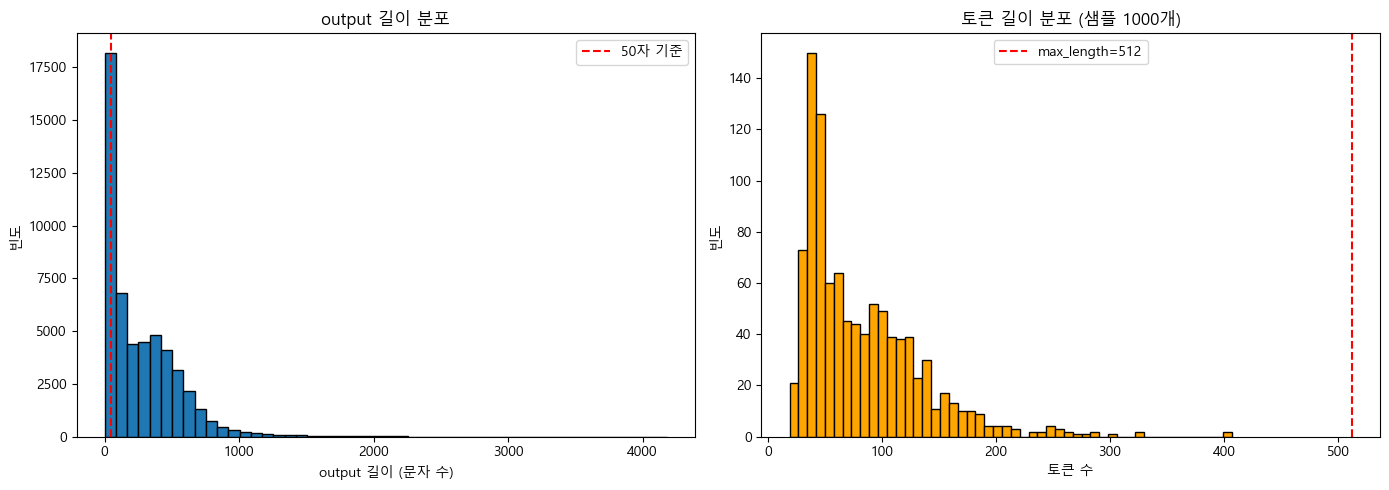


토큰 길이 통계 (샘플 1000개):
  평균: 82 토큰
  최대: 407 토큰
  512 초과: 0개 (0.0%) -> truncation됨


In [10]:
# === 데이터 품질 점검: 파인튰닝 성공의 80%는 데이터 품질 ===
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

train = dataset['train']

# 1) output 길이 분포 확인
output_lengths = [len(x['output']) for x in train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(output_lengths, bins=50, edgecolor='black')
axes[0].set_xlabel('output 길이 (문자 수)')
axes[0].set_ylabel('빈도')
axes[0].set_title('output 길이 분포')
axes[0].axvline(x=50, color='r', linestyle='--', label='50자 기준')
axes[0].legend()

# 2) 토큰 길이 분포 (max_length 설정에 중요)
tokenizer = AutoTokenizer.from_pretrained('gpt2')
# 샘플 1000개만 토큰화 (전체는 너무 오래 걸림)
sample_texts = [format_alpaca(train[i])['text'] for i in range(1000)]
token_lengths = [len(tokenizer.encode(t)) for t in sample_texts]

axes[1].hist(token_lengths, bins=50, edgecolor='black', color='orange')
axes[1].set_xlabel('토큰 수')
axes[1].set_ylabel('빈도')
axes[1].set_title('토큰 길이 분포 (샘플 1000개)')
axes[1].axvline(x=512, color='r', linestyle='--', label='max_length=512')
axes[1].legend()

plt.tight_layout()
plt.show()

# 통계
over_512 = sum(1 for l in token_lengths if l > 512)
print(f"\n토큰 길이 통계 (샘플 1000개):")
print(f"  평균: {sum(token_lengths)/len(token_lengths):.0f} 토큰")
print(f"  최대: {max(token_lengths)} 토큰")
print(f"  512 초과: {over_512}개 ({over_512/10:.1f}%) -> truncation됨")

In [11]:
# === 데이터 정제 파이프라인 ===
def clean_dataset(dataset):
    """Alpaca 데이터셋 정제"""
    original_size = len(dataset)

    # 1) output이 너무 짧은 샘플 제거 (50자 미만)
    dataset = dataset.filter(lambda x: len(x['output']) >= 50)
    after_length = len(dataset)

    # 2) instruction이 비어있는 샘플 제거
    dataset = dataset.filter(lambda x: len(x['instruction'].strip()) > 0)
    after_empty = len(dataset)

    # 3) 중복 제거 (instruction 기준)
    seen = set()
    def remove_duplicates(example):
        key = example['instruction'][:100]  # 앞 100자로 중복 판단
        if key in seen:
            return False
        seen.add(key)
        return True
    dataset = dataset.filter(remove_duplicates)
    after_dedup = len(dataset)

    print(f"데이터 정제 결과:")
    print(f"  원본: {original_size:,}개")
    print(f"  길이 필터: {after_length:,}개 (-{original_size - after_length})")
    print(f"  빈 제거: {after_empty:,}개 (-{after_length - after_empty})")
    print(f"  중복 제거: {after_dedup:,}개 (-{after_empty - after_dedup})")
    print(f"  최종: {after_dedup:,}개 ({after_dedup/original_size*100:.1f}% 남음)")

    return dataset

cleaned = clean_dataset(dataset['train'])

Filter: 100%|██████████| 39893/39893 [00:00<00:00, 109162.05 examples/s]

데이터 정제 결과:
  원본: 52,002개
  길이 필터: 39,893개 (-12109)
  빈 제거: 39,893개 (-0)
  중복 제거: 39,893개 (-0)
  최종: 39,893개 (76.7% 남음)


---
## 5. 데이터 형식 비교

In [12]:
# === 3가지 데이터 형식 예시 ===

# 1. Alpaca 형식 (단일 턴)
alpaca_example = {
    "instruction": "Python으로 피보나치 수열을 출력하세요.",
    "input": "10개까지",
    "output": "a, b = 0, 1\nfor _ in range(10):\n    print(a)\n    a, b = b, a + b",
}

# 2. ShareGPT 형식 (멀티 턴)
sharegpt_example = {
    "conversations": [
        {"from": "human", "value": "Python으로 피보나치 수열을 출력하는 방법을 알려줘."},
        {"from": "gpt", "value": "a, b = 0, 1\nfor _ in range(10):\n    print(a)\n    a, b = b, a + b"},
        {"from": "human", "value": "재귀로도 구현해줘."},
        {"from": "gpt", "value": "def fib(n):\n    if n <= 1: return n\n    return fib(n-1) + fib(n-2)"},
    ]
}

# 3. ChatML 형식
chatml_example = """<|im_start|>user
Python\uc73c\ub85c \ud53c\ubcf4\ub098\uce58 \uc218\uc5f4\uc744 \ucd9c\ub825\ud558\ub294 \ubc29\ubc95\uc744 \uc54c\ub824\uc918.<|im_end|>
<|im_start|>assistant
a, b = 0, 1
for _ in range(10):
    print(a)
    a, b = b, a + b<|im_end|>"""

print("1. Alpaca 형식 (단일 턴):")
print(f"   instruction: {alpaca_example['instruction']}")
print(f"   input: {alpaca_example['input']}")
print(f"   output: {alpaca_example['output'][:40]}...")

print(f"\n2. ShareGPT 형식 (멀티 턴):")
for msg in sharegpt_example['conversations']:
    print(f"   [{msg['from']}]: {msg['value'][:40]}...")

print(f"\n3. ChatML 형식:")
print(f"   {chatml_example[:100]}...")

print("\n\ud30c\uc778\ud2b0\ub2dd \uc2dc \uc120\ud0dd \uae30\uc900:")
print("  \ub2e8\uc77c QA/\uc791\uc5c5 -> Alpaca")
print("  \uba40\ud2f0\ud134 \ub300\ud654 -> ShareGPT")
print("  \ud2b9\uc815 \ubaa8\ub378 chat template -> ChatML / Llama \ud615\uc2dd")

1. Alpaca 형식 (단일 턴):
   instruction: Python으로 피보나치 수열을 출력하세요.
   input: 10개까지
   output: a, b = 0, 1
for _ in range(10):
    prin...

2. ShareGPT 형식 (멀티 턴):
   [human]: Python으로 피보나치 수열을 출력하는 방법을 알려줘....
   [gpt]: a, b = 0, 1
for _ in range(10):
    prin...
   [human]: 재귀로도 구현해줘....
   [gpt]: def fib(n):
    if n <= 1: return n
    ...

3. ChatML 형식:
   <|im_start|>user
Python으로 피보나치 수열을 출력하는 방법을 알려줘.<|im_end|>
<|im_start|>assistant
a, b = 0, 1
for _ i...

파인튰닝 시 선택 기준:
  단일 QA/작업 -> Alpaca
  멀티턴 대화 -> ShareGPT
  특정 모델 chat template -> ChatML / Llama 형식


---
## 정리

| 개념 | 핵심 |
|------|------|
| **load_dataset()** | Hub에서 즉시 로드, 로컬 파일도 지원 |
| **map()** | 데이터 변환 핵심 (포맷팅, 토큰화) |
| **filter()** | 품질 기준 필터링 |
| **3가지 형식** | Alpaca(단일턴), ShareGPT(멀티턴), ChatML |
| **데이터 품질** | 파인튰닝 성공의 80% |